In [1]:
import pandas as pd

data = pd.read_csv("../data/raw/bbc-text.csv")
data.head()

,category,text
0,tech,tv future in the hands of viewers with home th...
1,business,worldcom boss left books alone former worldc...
2,sport,tigers wary of farrell gamble leicester say ...
3,sport,yeading face newcastle in fa cup premiership s...
4,entertainment,ocean s twelve raids box office ocean s twelve...


In [3]:
data.columns

Index(['category', 'text'], dtype='object')

In [4]:
data.shape

(2225, 2)

In [12]:
data.isna().sum()

category    0
text        0
dtype: int64

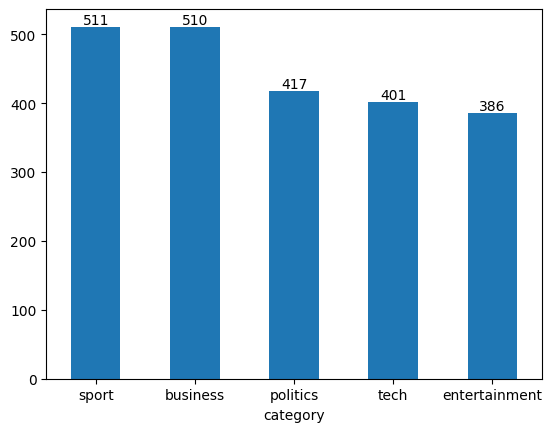

In [3]:
ax = data["category"].value_counts().plot.bar(rot=0)

for cont in ax.containers:
    ax.bar_label(cont)

In [10]:
max_len = 0
for i,sent in enumerate(data["text"]):
    sent_len = len(sent.split())
    # print(sent.split())
    # print(len(sent.split()),end=" ")
    if sent_len > max_len:
        max_len = sent_len
        print(i)

max_len

0
45
227
408


4492

In [18]:
data['text'].iloc[408]

'terror powers expose  tyranny  the lord chancellor has defended government plans to introduce control orders to keep foreign and british terrorist suspects under house arrest  where there isn t enough evidence to put them on trial.  lord falconer insists that the proposals do not equate to a police state and strike a balance between protecting the public against the threat of terrorism and upholding civil liberties. but thriller writer frederick forsyth tells bbc news of his personal response to the move.    there is a mortal danger aimed at the heart of britain. or so says home secretary charles clarke. my reaction  so what  it is not that i am cynical or just do not care. i care about this country very much.  but in the 66 years that i have been alive  there has not been one hour  of one day  of one month  of one year  when there has not been a threat aimed at us. my point is  the british have always coped without becoming a dictatorship. we have coped with fear without becoming a s

The following are the findings from dataset:
- Columns: category and text. text(column) --> input features and category(category) --> labels.
- text (column): contains texts (paragaphs)
- category column: contains labels.
- Total samples: 2225
- labels: sport, business, politics, tech, entertainment (5 classes)
- multi-class classification
- text data contains: special characters, numbers.
- max length of tokens: 4492

# Create test set

In [2]:
from sklearn.model_selection import train_test_split

train_set_full, test_set = train_test_split(data, test_size=0.2, stratify=data["category"], random_state=42, shuffle=True)
train_set_full.shape, test_set.shape

((1780, 2), (445, 2))

In [3]:
train_set, valid_set = train_test_split(train_set_full, test_size=0.1, stratify=train_set_full["category"],
                                        random_state=42)

In [75]:
train_set.set_index("category").to_csv("../data/train.csv", index=True)
valid_set.to_csv("../data/valid_set.csv", index=False)
test_set.set_index("category").to_csv("../data/test.csv", index=True)

<Axes: xlabel='category'>

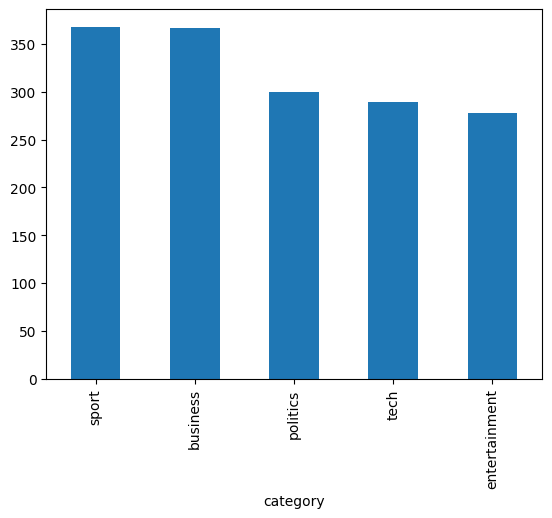

In [6]:
train_set["category"].value_counts().plot.bar()

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_encoded = le.fit_transform(train_set["category"])


In [23]:
le.classes_

array(['business', 'entertainment', 'politics', 'sport', 'tech'],
      dtype=object)

In [46]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(y_encoded)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_encoded)
class_weight_dict = dict(zip(classes.tolist(), weights.tolist()))
print("Class Weights:", class_weight_dict)


Class Weights: {0: 0.8725490196078431, 1: 1.1521035598705502, 2: 1.0690690690690692, 3: 0.8704156479217604, 4: 1.1090342679127725}


In [70]:
import yaml

data_yml = {
    "max_length": max_len,
    "vocab_size": 1000,
    "classes": {str(c): i for i,c in enumerate(le.classes_)},
    "class_weights": class_weight_dict
}

data_yml


{'max_length': 4492,
 'vocab_size': 1000,
 'classes': {'business': 0,
  'entertainment': 1,
  'politics': 2,
  'sport': 3,
  'tech': 4},
 'class_weights': {0: 0.8725490196078431,
  1: 1.1521035598705502,
  2: 1.0690690690690692,
  3: 0.8704156479217604,
  4: 1.1090342679127725}}

In [71]:
with open("../configs/data_configs.yml", "w") as f:
    yaml.dump(data_yml, f)

<Axes: xlabel='category'>

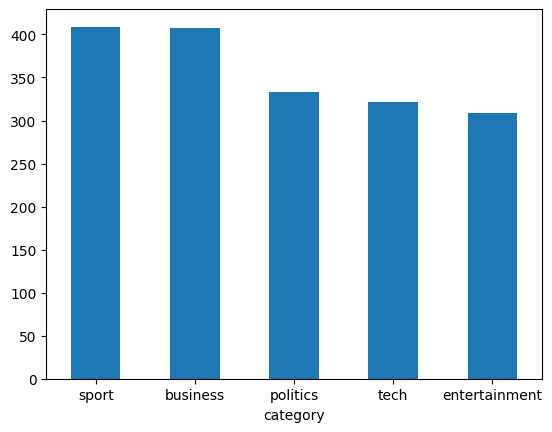

In [53]:
train_set["category"].value_counts().plot.bar(rot=0)